In [ ]:
pip install timm einops torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 23.2 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import numpy as np

!pip install kagglehub

In [ ]:
import kagglehub

# Download latest version of CheXpert
path = kagglehub.dataset_download("ashery/chexpert")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'chexpert' dataset.
Path to dataset files: /kaggle/input/chexpert


In [ ]:
import os

os.listdir("/kaggle/input/chexpert")



['valid.csv', 'valid', 'train.csv', 'train']

In [ ]:
import os
DATA_ROOT = "/kaggle/input/chexpert"
TRAIN_ROOT = "/kaggle/input/chexpert/train"
VALID_ROOT = "/kaggle/input/chexpert/valid"
os.listdir(TRAIN_ROOT)[:5]




['patient00734',
 'patient28598',
 'patient32985',
 'patient43625',
 'patient46811']

In [ ]:
import os

patient = os.listdir(TRAIN_ROOT)[0]
study = os.listdir(os.path.join(TRAIN_ROOT, patient))[0]
files = os.listdir(os.path.join(TRAIN_ROOT, patient, study))

print(patient, study, files)



patient00734 study3 ['view2_lateral.jpg', 'view1_frontal.jpg']


In [ ]:
from torchvision import transforms


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])


In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])


In [ ]:
class CheXpertUnsupervised(Dataset):
    def __init__(self, root, transform):
        self.paths = []
        for root_, _, files in os.walk(root):
            for f in files:
                if f.endswith(".jpg"):
                    self.paths.append(os.path.join(root_, f))
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img)


In [ ]:
TRAIN_ROOT = "/kaggle/input/chexpert/train"

dataset = CheXpertUnsupervised(
    root=TRAIN_ROOT,
    transform=transform
)

print("Total images:", len(dataset))


Total images: 223415


In [ ]:
loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)


In [ ]:
images = next(iter(loader))   # [B, 3, 224, 224]
images = images.cuda() if torch.cuda.is_available() else images


In [ ]:
import torch.nn.functional as F

# Unfold into patches
patches = F.unfold(
    images,
    kernel_size=16,
    stride=16
)
# shape: [B, 3*16*16, 196]

patches = patches.transpose(1, 2)
# shape: [B, 196, 768]


In [ ]:
import torch

grid_size = 14
coords = []

for i in range(grid_size):
    for j in range(grid_size):
        coords.append([i, j])

coords = torch.tensor(coords, dtype=torch.float32)  # [196, 2]
coords = coords.to(images.device)


In [ ]:
diff = coords[:, None, :] - coords[None, :, :]
dist = torch.norm(diff, dim=-1)  # [196, 196]


In [ ]:
sigma = 2.0  # hyperparameter
P_ij = torch.exp(-dist**2 / (2 * sigma**2))


In [ ]:
patch_feats = patches[0]   # take 1 image → [196, 768]
patch_feats = torch.nn.functional.normalize(patch_feats, dim=-1)


In [ ]:
S_ij = patch_feats @ patch_feats.T   # [196, 196]


In [ ]:
# simple thresholded co-activation
activation = (patch_feats.mean(dim=-1) > 0).float()  # [196]


In [ ]:
C_ij = activation[:, None] * activation[None, :]


In [ ]:
from torchvision import transforms

aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1.0)
])

images_aug = aug(images)


In [ ]:
patches_aug = F.unfold(
    images_aug,
    kernel_size=16,
    stride=16
).transpose(1, 2)

patch_feats_aug = torch.nn.functional.normalize(patches_aug[0], dim=-1)


In [ ]:
S_ij_aug = patch_feats_aug @ patch_feats_aug.T
T_ij = 1.0 - torch.abs(S_ij - S_ij_aug)


In [ ]:
alpha, beta, gamma, delta = 0.25, 0.25, 0.25, 0.25

A_ij = (
    alpha * S_ij +
    beta  * P_ij +
    gamma * C_ij +
    delta * T_ij
)

A_ij = torch.clamp(A_ij, 0, 1)


In [ ]:
import numpy as np

A_ij_np = A_ij.detach().cpu().numpy()
np.save("A_ij.npy", A_ij_np)

print("Saved A_ij.npy with shape:", A_ij_np.shape)


Saved A_ij.npy with shape: (196, 196)


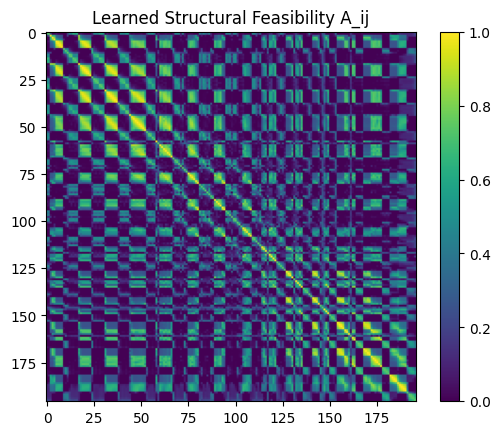

tensor([[0.7500, 0.7001, 0.1121, 0.0000, 0.0000],
        [0.7001, 0.7500, 0.2586, 0.0000, 0.0000],
        [0.1121, 0.2586, 1.0000, 0.6626, 0.6488],
        [0.0000, 0.0000, 0.6626, 1.0000, 0.8321],
        [0.0000, 0.0000, 0.6488, 0.8321, 1.0000]], device='cuda:0')

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(A_ij.detach().cpu())
plt.colorbar()
plt.title("Learned Structural Feasibility A_ij")
plt.show()
A_ij[:5, :5]



In [ ]:
import os
import copy
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

from PIL import Image
import timm
from torch.amp import autocast, GradScaler


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
IMAGE_ROOT = "/kaggle/input/chexpert"

LABELS = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Pleural Effusion"
]

NUM_LABELS = len(LABELS)

EPOCHS = 20
PATIENCE = 5
BATCH_SIZE = 16
LR = 2e-5
WEIGHT_DECAY = 1e-4


In [ ]:
DATA_DIR = "/kaggle/input/chexpert"

train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
valid_df = pd.read_csv(os.path.join(DATA_DIR, "valid.csv"))


In [ ]:
def preprocess_labels(df):
    df = df.copy()
    df[LABELS] = df[LABELS].fillna(0)
    df[LABELS] = df[LABELS].replace(-1, 0)
    return df

train_df = preprocess_labels(train_df)
valid_df = preprocess_labels(valid_df)


In [ ]:
# IMPORTANT: keep paths relative to /kaggle/input/chexpert
train_df["Path"] = train_df["Path"].str.replace(
    "CheXpert-v1.0-small/", "", regex=False
)
valid_df["Path"] = valid_df["Path"].str.replace(
    "CheXpert-v1.0-small/", "", regex=False
)


In [ ]:
train_df_sub, test_df = train_test_split(
    train_df, test_size=0.1, random_state=42
)

# Use 20% of training subset (same spirit as Swin baseline)
train_df_sub = train_df_sub.sample(frac=0.2, random_state=42)

print(
    "Train:", len(train_df_sub),
    "Val:", len(valid_df),
    "Test:", len(test_df)
)


Train: 40214 Val: 234 Test: 22342


In [ ]:
from transformers import AutoImageProcessor

processor = AutoImageProcessor.from_pretrained(
    "microsoft/swin-base-patch4-window7-224"
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [ ]:
class CheXpertDataset(Dataset):
    def __init__(self, df, image_root, processor):
        self.df = df.reset_index(drop=True)
        self.image_root = image_root
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = os.path.join(self.image_root, row["Path"])
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Missing image: {img_path}")

        image = Image.open(img_path).convert("RGB")

        inputs = self.processor(images=image, return_tensors="pt")
        pixel_values = inputs["pixel_values"].squeeze(0)

        labels = torch.from_numpy(
          row[LABELS].to_numpy(dtype=np.float32)
          )


        return pixel_values, labels


In [ ]:
train_loader = DataLoader(
    CheXpertDataset(train_df_sub, IMAGE_ROOT, processor),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    CheXpertDataset(valid_df, IMAGE_ROOT, processor),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    CheXpertDataset(test_df, IMAGE_ROOT, processor),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
x, y = train_loader.dataset[0]
print(x.shape, y)
A_ij = np.load("A_ij.npy")           # shape [196, 196]
A_ij = torch.tensor(A_ij).float().to(device)

print("Loaded A_ij:", A_ij.shape)


torch.Size([3, 224, 224]) tensor([0., 0., 0., 0., 0.])
Loaded A_ij: torch.Size([196, 196])


In [ ]:
class ViTWithAij(nn.Module):
    def __init__(self, num_labels, A_ij):
        super().__init__()
        self.vit = timm.create_model(
            "vit_base_patch16_224",
            pretrained=True,
            num_classes=num_labels
        )
        self.A_ij = A_ij  # [196, 196]

    def forward(self, x):
        # Patch embedding
        x = self.vit.patch_embed(x)          # [B, 196, D]
        B, N, D = x.shape

        # Apply structural feasibility
        B = x.size(0)
        A = self.A_ij.unsqueeze(0).expand(B, -1, -1)  # [B, 196, 196]
        x = torch.bmm(A, x) # [B, 196, D]

        # CLS token
        cls_token = self.vit.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_token, x), dim=1)

        x = x + self.vit.pos_embed
        x = self.vit.pos_drop(x)

        for blk in self.vit.blocks:
            x = blk(x)

        x = self.vit.norm(x)
        cls_out = x[:, 0]

        logits = self.vit.head(cls_out)
        return logits


In [ ]:
model = ViTWithAij(NUM_LABELS, A_ij).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scaler = GradScaler()

best_auc = 0.0
patience_counter = 0
best_model_wts = None

for epoch in range(EPOCHS):

    # ===== TRAIN =====
    model.train()
    train_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # ✅ FIXED autocast
        with autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ===== VALIDATION =====
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # ✅ FIXED autocast
            with autocast("cuda"):
                outputs = model(images)

            probs = torch.sigmoid(outputs)
            preds.append(probs.cpu().numpy())
            targets.append(labels.cpu().numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)

    auc = roc_auc_score(targets, preds, average="macro")

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val AUC: {auc:.4f}"
    )

    # ===== EARLY STOPPING =====
    if auc > best_auc:
        best_auc = auc
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping triggered")
            break


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Epoch 1: 100%|██████████| 2514/2514 [06:27<00:00,  6.49it/s]


Epoch 1 | Train Loss: 0.4412 | Val AUC: 0.6914


Epoch 2: 100%|██████████| 2514/2514 [06:23<00:00,  6.56it/s]


Epoch 2 | Train Loss: 0.4319 | Val AUC: 0.7224


...

Epoch 10 | Train Loss: 0.3987 | Val AUC: 0.7195


Epoch 11: 100%|██████████| 2514/2514 [06:24<00:00,  6.54it/s]


Epoch 11 | Train Loss: 0.3895 | Val AUC: 0.7215


Epoch 12: 100%|██████████| 2514/2514 [06:23<00:00,  6.55it/s]


Epoch 12 | Train Loss: 0.3760 | Val AUC: 0.7144
Early stopping triggered


In [ ]:
CHECKPOINT_PATH = "vit_base_Aij_best.pt"
torch.save(best_model_wts, CHECKPOINT_PATH)

print("Saved best Model C to:", CHECKPOINT_PATH)


Saved best Model C to: vit_base_Aij_best.pt


In [ ]:
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.eval()

preds, targets = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        logits = model(imgs)
        probs = torch.sigmoid(logits)

        preds.append(probs.cpu().numpy())
        targets.append(labels.cpu().numpy())

preds = np.concatenate(preds)
targets = np.concatenate(targets)

print("Test Macro AUC:", roc_auc_score(targets, preds, average="macro"))

print("\nPer-class Test AUC:")
for i, label in enumerate(LABELS):
    print(
        f"{label:20s}: "
        f"{roc_auc_score(targets[:, i], preds[:, i]):.4f}"
    )


Test Macro AUC: 0.6619903442417865

Per-class Test AUC:
Atelectasis         : 0.5769
Cardiomegaly        : 0.6735
Consolidation       : 0.6227
Edema               : 0.7300
Pleural Effusion    : 0.7068


In [ ]:
def prediction_stability(model, image, trials=5, noise_std=0.01):
    model.eval()
    outputs = []

    with torch.no_grad():
        for _ in range(trials):
            noisy = image + noise_std * torch.randn_like(image)
            logits = model(noisy.unsqueeze(0).to(device))
            outputs.append(torch.sigmoid(logits).cpu().numpy())

    outputs = np.array(outputs)
    return outputs.var(axis=0).mean()


In [ ]:
def test_prediction_stability(
    model,
    dataset,
    num_samples=50,
    trials=5,
    noise_std=0.01
):
    stabilities = []
    for i in range(num_samples):
        image, _ = dataset[i]
        stabilities.append(
            prediction_stability(
                model, image, trials, noise_std
            )
        )
    return float(np.mean(stabilities))

In [ ]:
test_stability = test_prediction_stability(
    model=model,
    dataset=test_loader.dataset
)

print(f"🧠 Test Prediction Stability (↓ better): {test_stability:.6f}")


🧠 Test Prediction Stability (↓ better): 0.000000
